In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
pip install opencv-python numpy matplotlib

In [11]:
import zipfile, os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("BSDS500")

print("Files extracted!")

Files extracted!


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from glob import glob

In [14]:
image_paths = glob("BSDS500/archive/images/train/*.jpg")
print(len(image_paths))

200


In [23]:

if len(image_paths) > 0:
    selected_image_path = image_paths[10]
    print(f"Using image: {selected_image_path}")
else:
    selected_image_path = None
    print("Error: No image paths found. Please ensure images are extracted correctly.")

Using image: BSDS500/archive/images/train/249061.jpg


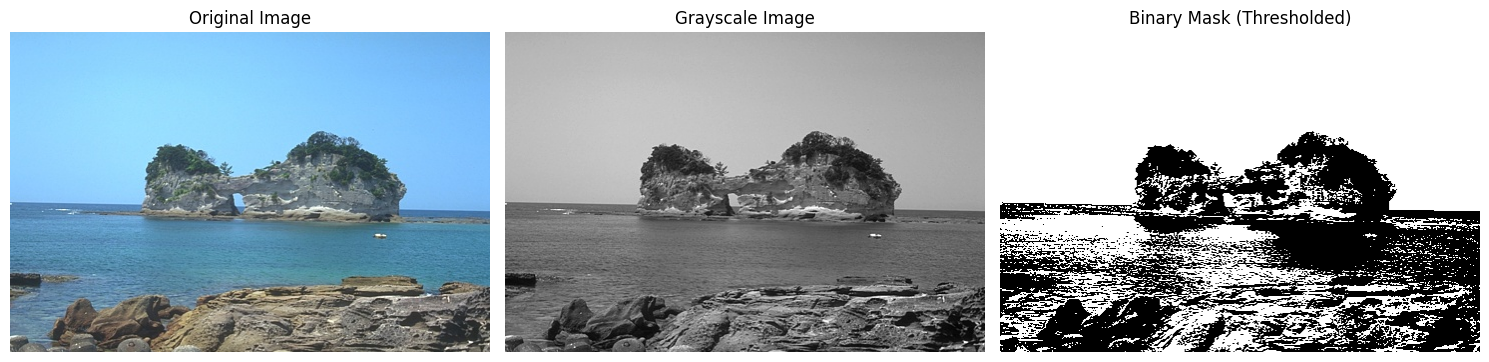

In [24]:
if selected_image_path:

    image = cv2.imread(selected_image_path)


    if image is None:
        print(f"Error: Could not load image from {selected_image_path}")
    else:

        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        ret, mask = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(gray_image, cmap='gray')
        plt.title('Grayscale Image')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(mask, cmap='gray')
        plt.title('Binary Mask (Thresholded)')
        plt.axis('off')

        plt.tight_layout()
        plt.show()
else:
    print("Cannot proceed without a valid image path.")

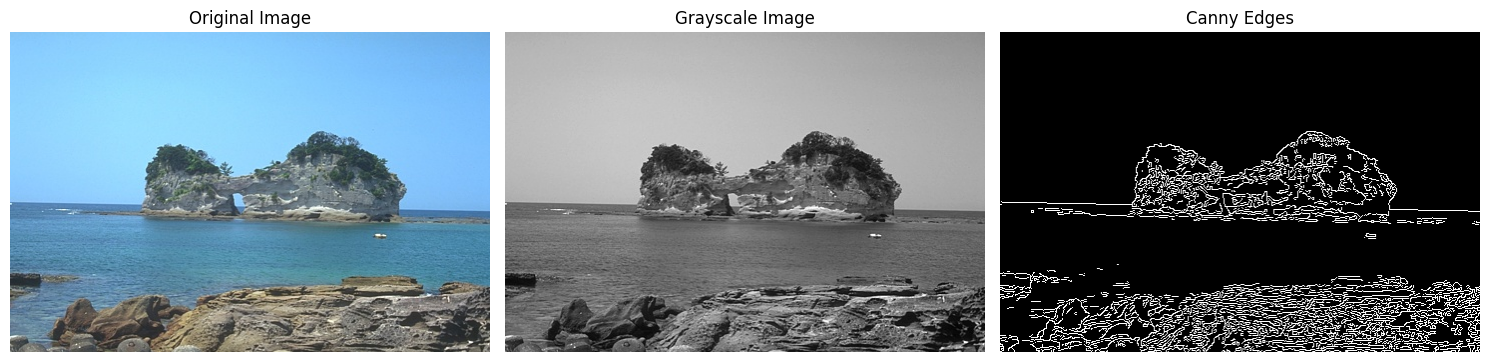

In [25]:
if selected_image_path and 'gray_image' in locals():

    low_threshold = 100
    high_threshold = 200
    edges = cv2.Canny(gray_image, low_threshold, high_threshold)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(edges, cmap='gray')
    plt.title('Canny Edges')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot proceed. Ensure an image is loaded and converted to grayscale first.")

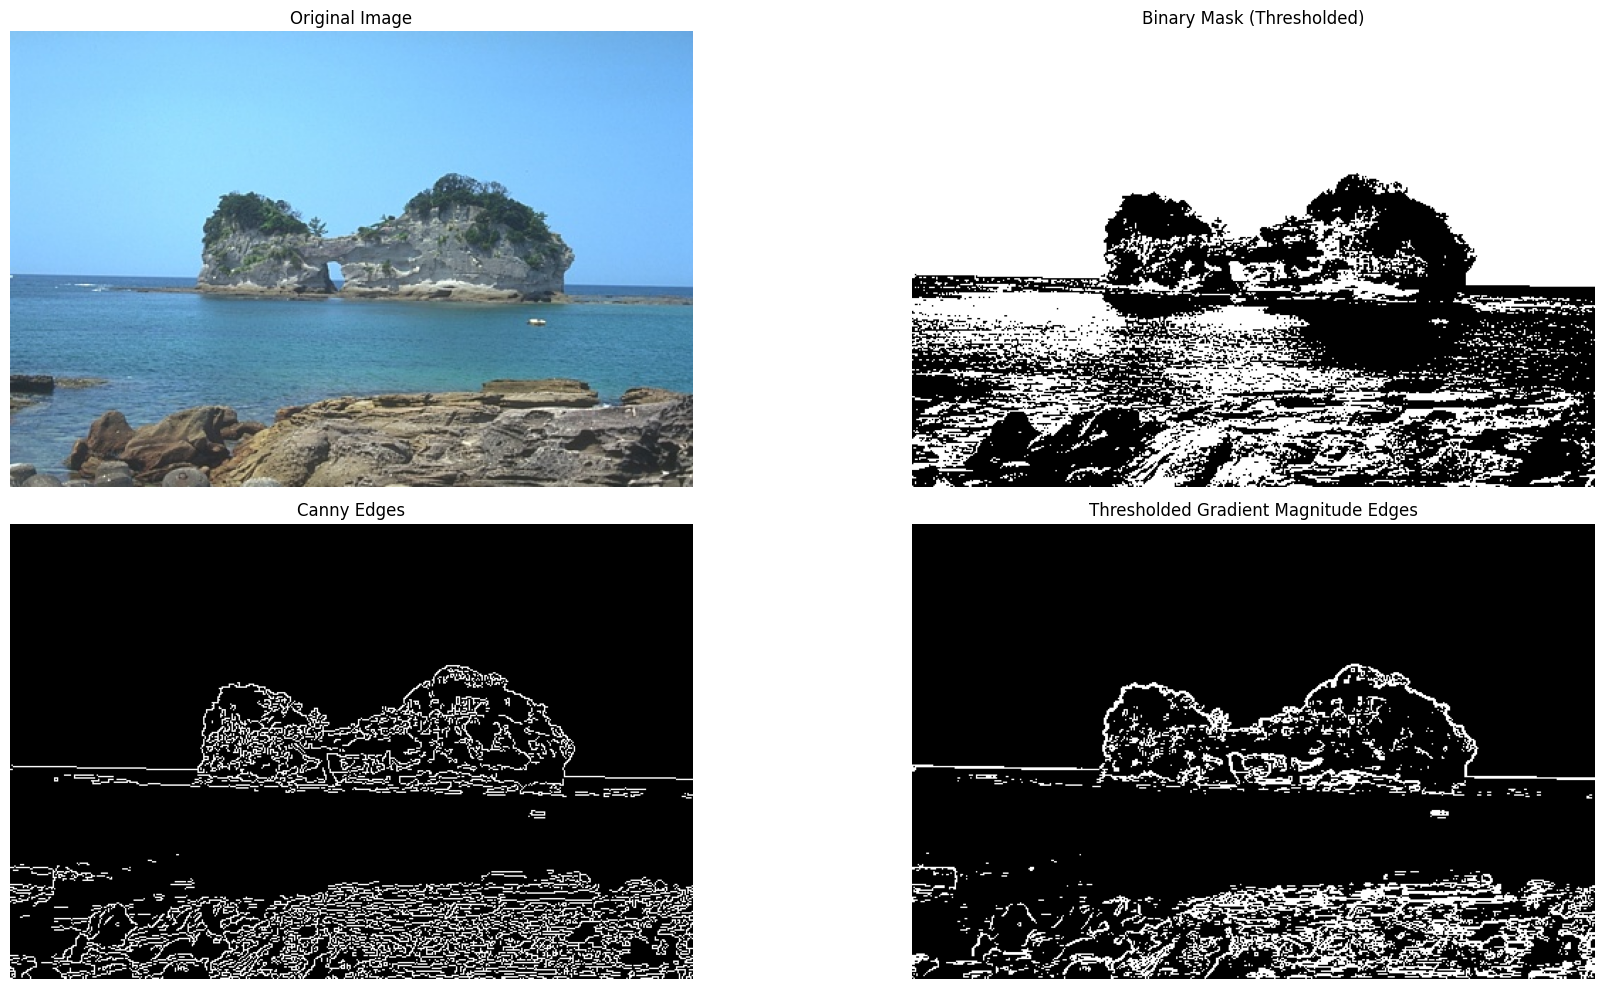

In [27]:
if selected_image_path and 'gray_image' in locals() and 'mask' in locals() and 'edges' in locals() and 'edges_from_magnitude' in locals():
    plt.figure(figsize=(20, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Binary Mask (Thresholded)')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(edges, cmap='gray')
    plt.title('Canny Edges')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(edges_from_magnitude, cmap='gray')
    plt.title('Thresholded Gradient Magnitude Edges')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot proceed. Ensure all image processing steps have been executed.")

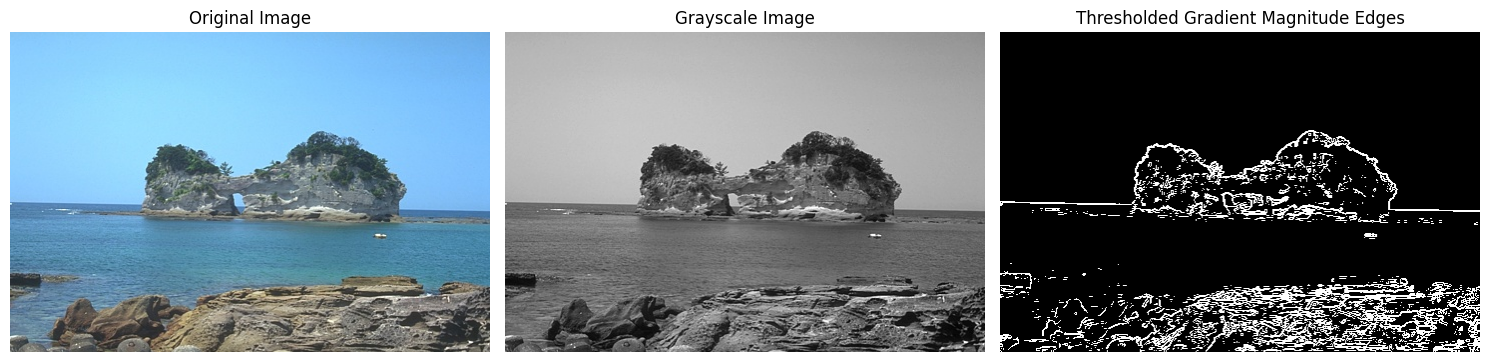

In [26]:
if selected_image_path and 'gray_image' in locals():

    grad_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)


    gradient_magnitude = cv2.magnitude(grad_x, grad_y)


    gradient_magnitude_norm = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)


    ret_mag, edges_from_magnitude = cv2.threshold(gradient_magnitude_norm, 50, 255, cv2.THRESH_BINARY)


    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(edges_from_magnitude, cmap='gray')
    plt.title('Thresholded Gradient Magnitude Edges')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot proceed. Ensure an image is loaded and converted to grayscale first.")

In [28]:
output_dir = 'processed_images'
masks_dir = os.path.join(output_dir, 'masks')
canny_dir = os.path.join(output_dir, 'canny_edges')
grad_mag_dir = os.path.join(output_dir, 'gradient_magnitude_edges')

for d in [masks_dir, canny_dir, grad_mag_dir]:
    os.makedirs(d, exist_ok=True)

print(f"Output directories created at: {output_dir}")

Output directories created at: processed_images


In [29]:
processed_count = 0
for img_path in image_paths:
    img_name = os.path.basename(img_path)

    image = cv2.imread(img_path)

    if image is None:
        print(f"Warning: Could not load image from {img_path}. Skipping.")
        continue

    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


    ret, mask = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
    cv2.imwrite(os.path.join(masks_dir, img_name), mask)


    low_threshold = 100
    high_threshold = 200
    edges = cv2.Canny(gray_image, low_threshold, high_threshold)
    cv2.imwrite(os.path.join(canny_dir, img_name), edges)


    grad_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = cv2.magnitude(grad_x, grad_y)
    gradient_magnitude_norm = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    ret_mag, edges_from_magnitude = cv2.threshold(gradient_magnitude_norm, 50, 255, cv2.THRESH_BINARY)
    cv2.imwrite(os.path.join(grad_mag_dir, img_name), edges_from_magnitude)

    processed_count += 1
    if processed_count % 50 == 0:
        print(f"Processed {processed_count}/{len(image_paths)} images...")

print(f"Finished processing {processed_count} images. Results saved in '{output_dir}'.")

Processed 50/200 images...
Processed 100/200 images...
Processed 150/200 images...
Processed 200/200 images...
Finished processing 200 images. Results saved in 'processed_images'.


Displaying a sample of processed images...


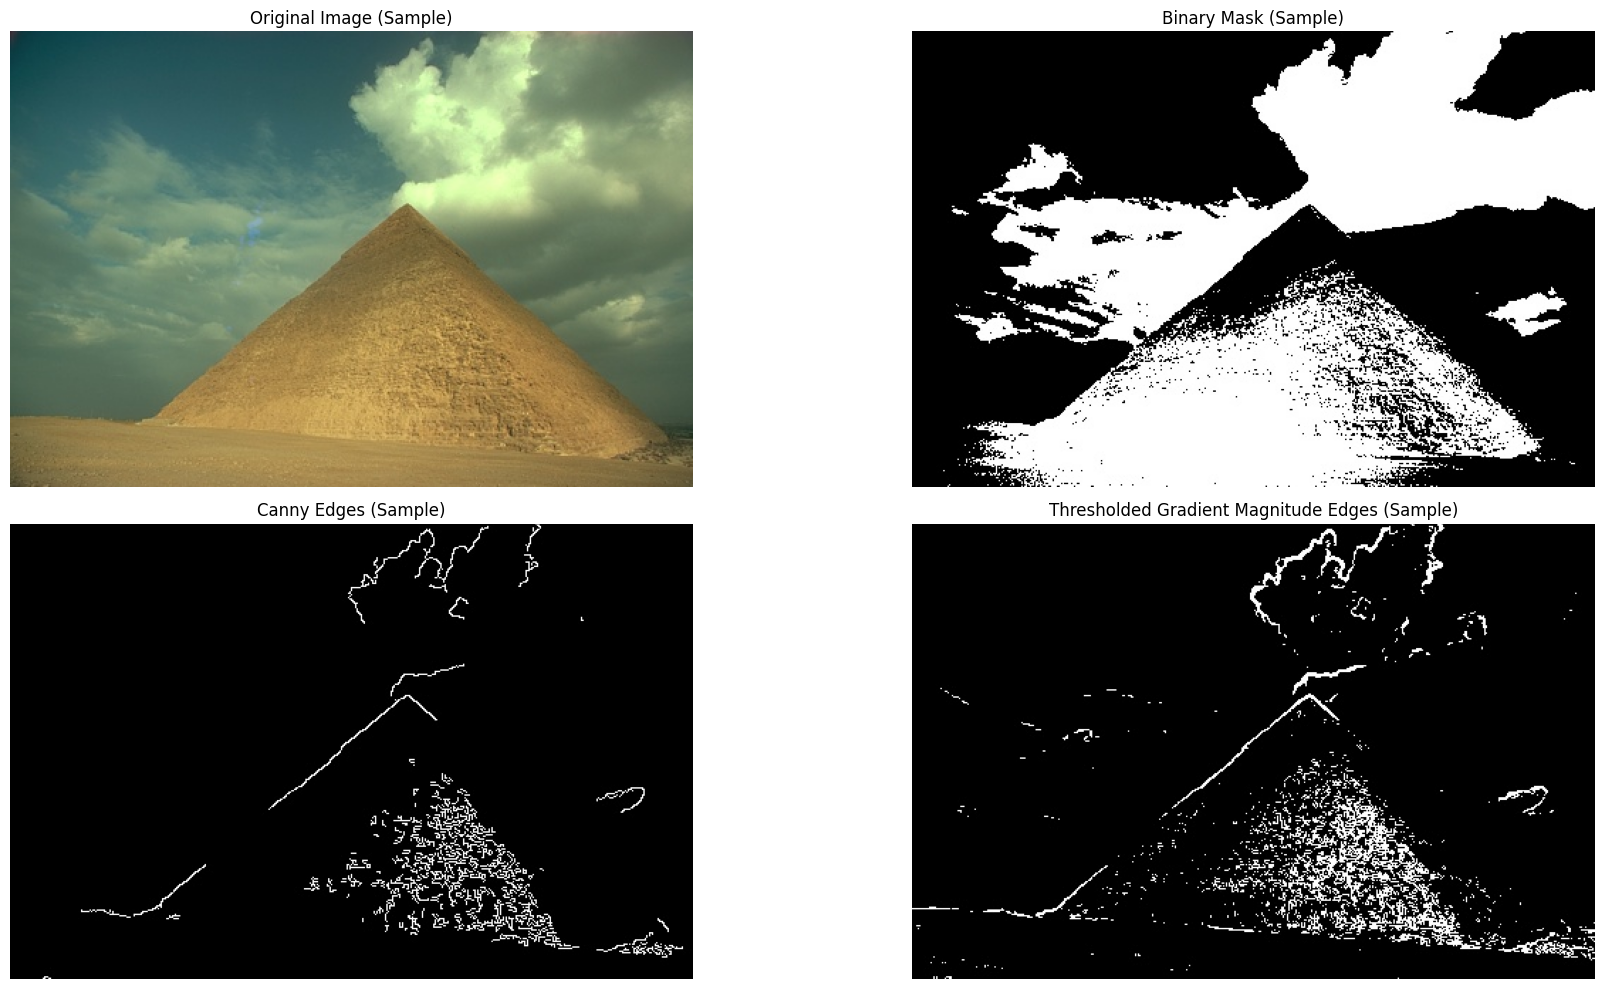

In [30]:
print("Displaying a sample of processed images...")

if processed_count > 0:
    sample_image_name = os.path.basename(image_paths[0])

    original_image = cv2.imread(image_paths[0])
    sample_mask = cv2.imread(os.path.join(masks_dir, sample_image_name), cv2.IMREAD_GRAYSCALE)
    sample_canny = cv2.imread(os.path.join(canny_dir, sample_image_name), cv2.IMREAD_GRAYSCALE)
    sample_grad_mag = cv2.imread(os.path.join(grad_mag_dir, sample_image_name), cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(20, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image (Sample)')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(sample_mask, cmap='gray')
    plt.title('Binary Mask (Sample)')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(sample_canny, cmap='gray')
    plt.title('Canny Edges (Sample)')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(sample_grad_mag, cmap='gray')
    plt.title('Thresholded Gradient Magnitude Edges (Sample)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No images were processed to display a sample.")